# Tibetan Research SDK Starter v2

This notebook exercises the SDK end to end and makes the recent SDK improvements observable in Jupyter.

## Expected behavior
- Repeated `sdk.embed_sentences(...)` calls with the same model-load settings should reuse one cached `TextEmbedder` instance.
- `sdk.pairwise(...)` should reuse the SDK's existing segmenter instead of resolving a new one internally.
- Model loading controls should flow through the SDK into the embedder: `torch_dtype`, `device_map`, and `load_in_8bit`.


In [1]:
import sys
import re
from pathlib import Path
from pprint import pprint
from time import perf_counter
from unittest.mock import patch

def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "tibetan_pipeline").exists() and (candidate / "requirements.txt").exists():
            return candidate
    raise RuntimeError("Could not find project root containing tibetan_pipeline/ and requirements.txt")

project_root = find_project_root(Path.cwd())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from tibetan_pipeline import TibetanResearchSDK

print(f"project_root={project_root}")

/home/thomas/Project_S/A03/tibetan-intertext-lab/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


project_root=/home/thomas/Project_S/A03/tibetan-intertext-lab


With an RTX 5070Ti:

1) 4 bit quantization works fine (occupies ~12G/16G).
2) 8 bit quantization works (occupies ~15G/16G).  

In [2]:
sdk = TibetanResearchSDK(
    engine="botok_ours",
    source_format="unicode",
    model_id="buddhist-nlp/gemma-2-mitra-e",
    device="cuda",
    batch_size=1,
    device_map={"":0},
    embedding_progress="batch",
    load_in_8bit=True,
)

sdk

# Data Loading
*Not part of the original notebook*  
## Introduction
We are loading all texts for the exploratory study from the texts/ folder.

In [3]:
from dataclasses import dataclass
from typing import List, Optional, Tuple
from tibetan_pipeline import SegmentationView, EmbeddingView

In [4]:
@dataclass
class TextData:
    name: str
    orig_text: str 
    segments: SegmentationView | None = None
    embeddings: EmbeddingView | None = None

    def __repr__(self):
            return (
                f"TextData("
                f"name={self.name!r}, "
                f"text_len={len(self.orig_text)}, "
                f"orig_text={self.orig_text[:25]}..., "
                f"segments={True if self.segments else False}, "
                f"embeddings={True if self.embeddings else False}"
                f")"
            )

## Preparing Texts

In [ ]:
# Loading all texts from folder
folder = Path("texts/")
text_list: List[TextData] = list()
for t in folder.glob("*.txt"):
    text_list.append(TextData(name=t.name, orig_text=t.read_text(encoding="utf-8")))

In [ ]:
# Sanity checks
print(text_list[0])

### Creating Segments (sentences)

In [ ]:
for t in text_list:
    print(f"Processing {t.name}...")
    t.segments = sdk.segment_text(t.orig_text)
print("Finished.")

In [ ]:
# Sanity check
text_list[0]

In [ ]:
text_list[0].segments.to_dataframe()

### Creating Embeddings

In [ ]:
# Only start if embeddings must be created, otherwise load pickle data in the following step
for t in text_list:
    print(f"Processing {t.name}...")
    #t.embeddings = sdk.embed_sentences(t.segments.segments)

In [ ]:
# Sanity check
text_list[0]

### Storing Data as pickle Files

In [ ]:
import pickle
filename = "data_8b_emb.pkl"
with open(f"data/{filename}", "wb") as f:
    pickle.dump(text_list, f, protocol=pickle.HIGHEST_PROTOCOL)

# Loading Processed Text Data
If embeddings have already been created, you can save the `TextData` list in a byte format an reload it at a later point.

In [5]:
import pickle

In [6]:
# Loading
filename = "data_8b_emb.pkl"
with open(f"data/{filename}", "rb") as f:
    loaded_data = pickle.load(f)

In [7]:
assert len(loaded_data) == 6

In [8]:
loaded_data

[TextData(name='04-SMDG-rig-pa-khu-byug-gzhung.txt', text_len=8573, orig_text=﻿[64]རིག་པ་ཁུ་བྱུག་གི་གཞུ..., segments=True, embeddings=True),
 TextData(name='05-SMDG-rig-pa-khu-byug-grel.txt', text_len=76568, orig_text=﻿[71]རིག་པ་ཁུ་བྱུག་གི་འགྲ..., segments=True, embeddings=True),
 TextData(name='V1b_rig-pa-khu-byug-vol4-267-271.txt', text_len=3356, orig_text=﻿ [267.3]
 ༎བཅོམ་ལྡན་འདས་ད..., segments=True, embeddings=True),
 TextData(name='V1a_khu-byug-vol5-306-308.txt', text_len=401, orig_text=﻿
 
 [306]རྒྱ་གར་སྐད་དུ། ས་..., segments=True, embeddings=True),
 TextData(name="L1-rig-pa'i-khu-byug_V9-p302-324.txt", text_len=23095, orig_text=﻿༄༅། །རྒྱ་གར་སྐད་དུ། སྭསྟ..., segments=True, embeddings=True),
 TextData(name='D1-rig-pa-khu-byug-comm_IOL-TJ647-karmay.txt', text_len=5257, orig_text=﻿སབ༹སྟི་དཔལ་གྱི་དཔལ།་བཅོམ..., segments=True, embeddings=True)]

In [9]:
loaded_data[0]

TextData(name='04-SMDG-rig-pa-khu-byug-gzhung.txt', text_len=8573, orig_text=﻿[64]རིག་པ་ཁུ་བྱུག་གི་གཞུ..., segments=True, embeddings=True)

In [10]:
loaded_data[0].segments.to_dataframe().head()

,segment_index,start,end,segment_text
0,0,0,50,﻿[64]རིག་པ་ཁུ་བྱུག་གི་གཞུང་བཞུགས་པའི་དབུ་ལགས་སོ།།
1,1,50,121,སྟོན་པ་གཤེན་ལྷ་འོད་དཀར་ཐམས་ཅད་མཁྱེན་པའི་ཡེ་ཤེས...
2,2,121,149,སྟོན་པ་ཐུགས་རྗེ་ཆེར་ལྡན་བས།
3,3,149,179,གསུང་ལས་སྤྲུལ་པའི་ཁུ་བྱུག་ནི།
4,4,179,208,ཡུམ་ལ་ཆགས་ནས་དངོས་པོར་བྱུང་།


# Exploratory Data Analysis

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
loaded_data

[TextData(name='04-SMDG-rig-pa-khu-byug-gzhung.txt', text_len=8573, orig_text=﻿[64]རིག་པ་ཁུ་བྱུག་གི་གཞུ..., segments=True, embeddings=True),
 TextData(name='05-SMDG-rig-pa-khu-byug-grel.txt', text_len=76568, orig_text=﻿[71]རིག་པ་ཁུ་བྱུག་གི་འགྲ..., segments=True, embeddings=True),
 TextData(name='V1b_rig-pa-khu-byug-vol4-267-271.txt', text_len=3356, orig_text=﻿ [267.3]
 ༎བཅོམ་ལྡན་འདས་ད..., segments=True, embeddings=True),
 TextData(name='V1a_khu-byug-vol5-306-308.txt', text_len=401, orig_text=﻿
 
 [306]རྒྱ་གར་སྐད་དུ། ས་..., segments=True, embeddings=True),
 TextData(name="L1-rig-pa'i-khu-byug_V9-p302-324.txt", text_len=23095, orig_text=﻿༄༅། །རྒྱ་གར་སྐད་དུ། སྭསྟ..., segments=True, embeddings=True),
 TextData(name='D1-rig-pa-khu-byug-comm_IOL-TJ647-karmay.txt', text_len=5257, orig_text=﻿སབ༹སྟི་དཔལ་གྱི་དཔལ།་བཅོམ..., segments=True, embeddings=True)]

                                   Name  Length
0    04-SMDG-rig-pa-khu-byug-gzhung.txt    8573
1      05-SMDG-rig-pa-khu-byug-grel.txt   76568
2  V1b_rig-pa-khu-byug-vol4-267-271.txt    3356
3         V1a_khu-byug-vol5-306-308.txt     401
4  L1-rig-pa'i-khu-byug_V9-p302-324.txt   23095


/tmp/ipykernel_25673/57327605.py:17: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


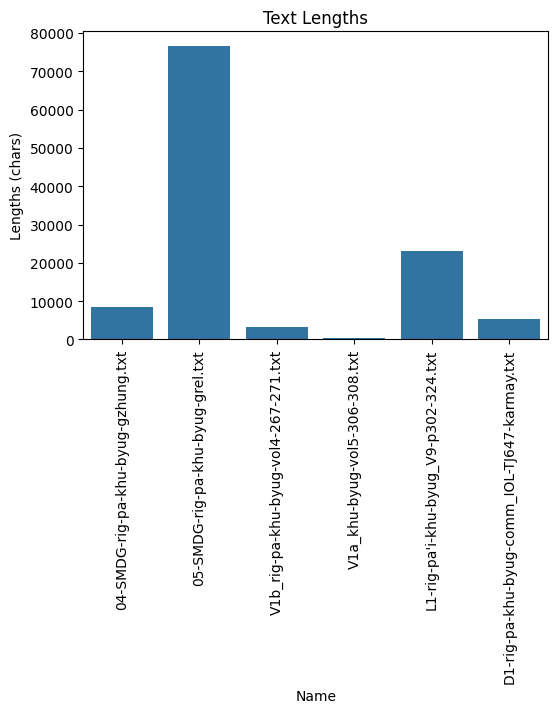

In [13]:
# Text lengths
import warnings
warnings.filterwarnings('ignore', category=UserWarning, message='Glyph.*missing from font')
df = pd.DataFrame({
    'Name': [t.name for t in loaded_data],
    'Length': [len(re.sub(f"\s{2,}", " ", t.orig_text)) for t in loaded_data]
})
print(df.head())

# Barplot erstellen
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='Name', y='Length')
plt.title('Text Lengths')
plt.xlabel('Name')
plt.ylabel('Lengths (chars)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("images/text_len.png", dpi=300, bbox_inches='tight')

                                   Name  Length
0    04-SMDG-rig-pa-khu-byug-gzhung.txt     221
1      05-SMDG-rig-pa-khu-byug-grel.txt    1241
2  V1b_rig-pa-khu-byug-vol4-267-271.txt      84
3         V1a_khu-byug-vol5-306-308.txt       8
4  L1-rig-pa'i-khu-byug_V9-p302-324.txt     516


/tmp/ipykernel_25673/3163402529.py:17: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


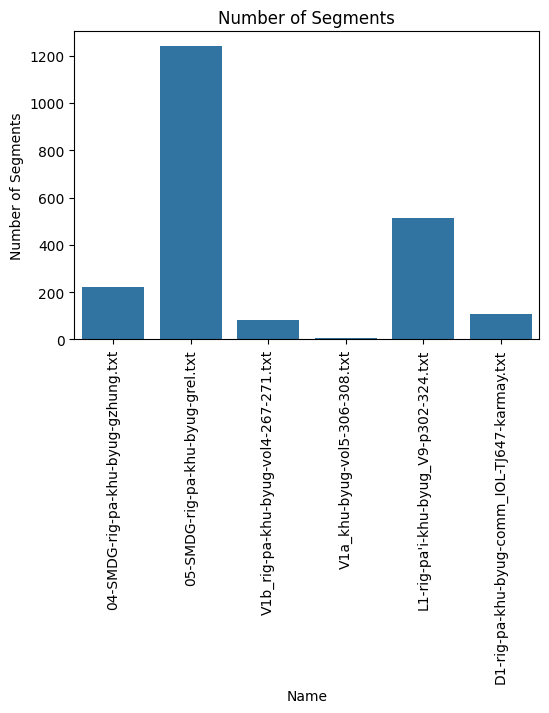

In [14]:
# Segment lengths
import warnings
warnings.filterwarnings('ignore', category=UserWarning, message='Glyph.*missing from font')
df = pd.DataFrame({
    'Name': [t.name for t in loaded_data],
    'Length': [len(t.segments.segments) for t in loaded_data]
})
print(df.head())

# Barplot erstellen
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='Name', y='Length')
plt.title('Number of Segments')
plt.xlabel('Name')
plt.ylabel('Number of Segments')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("images/segment_number.png", dpi=300, bbox_inches='tight')

In [15]:
loaded_data[0].embeddings.embeddings[0].size

3584

In [16]:
len(loaded_data)

6

# Pairwise analysis of texts

In [17]:
# Creating a result set with pairwise views for each text combination
from itertools import combinations

results = []
for text_a, text_b in combinations(loaded_data, 2):
    result = sdk.pairwise_from_embedding_views(text_a.embeddings, text_b.embeddings)
    results.append((text_a.name, text_b.name, result))

In [18]:
# Makes sense because of n! / k! * (n-k)! -> 6! / 2! * 4! -> 6 * 5 / 2 -> 15
assert len(results) == 15

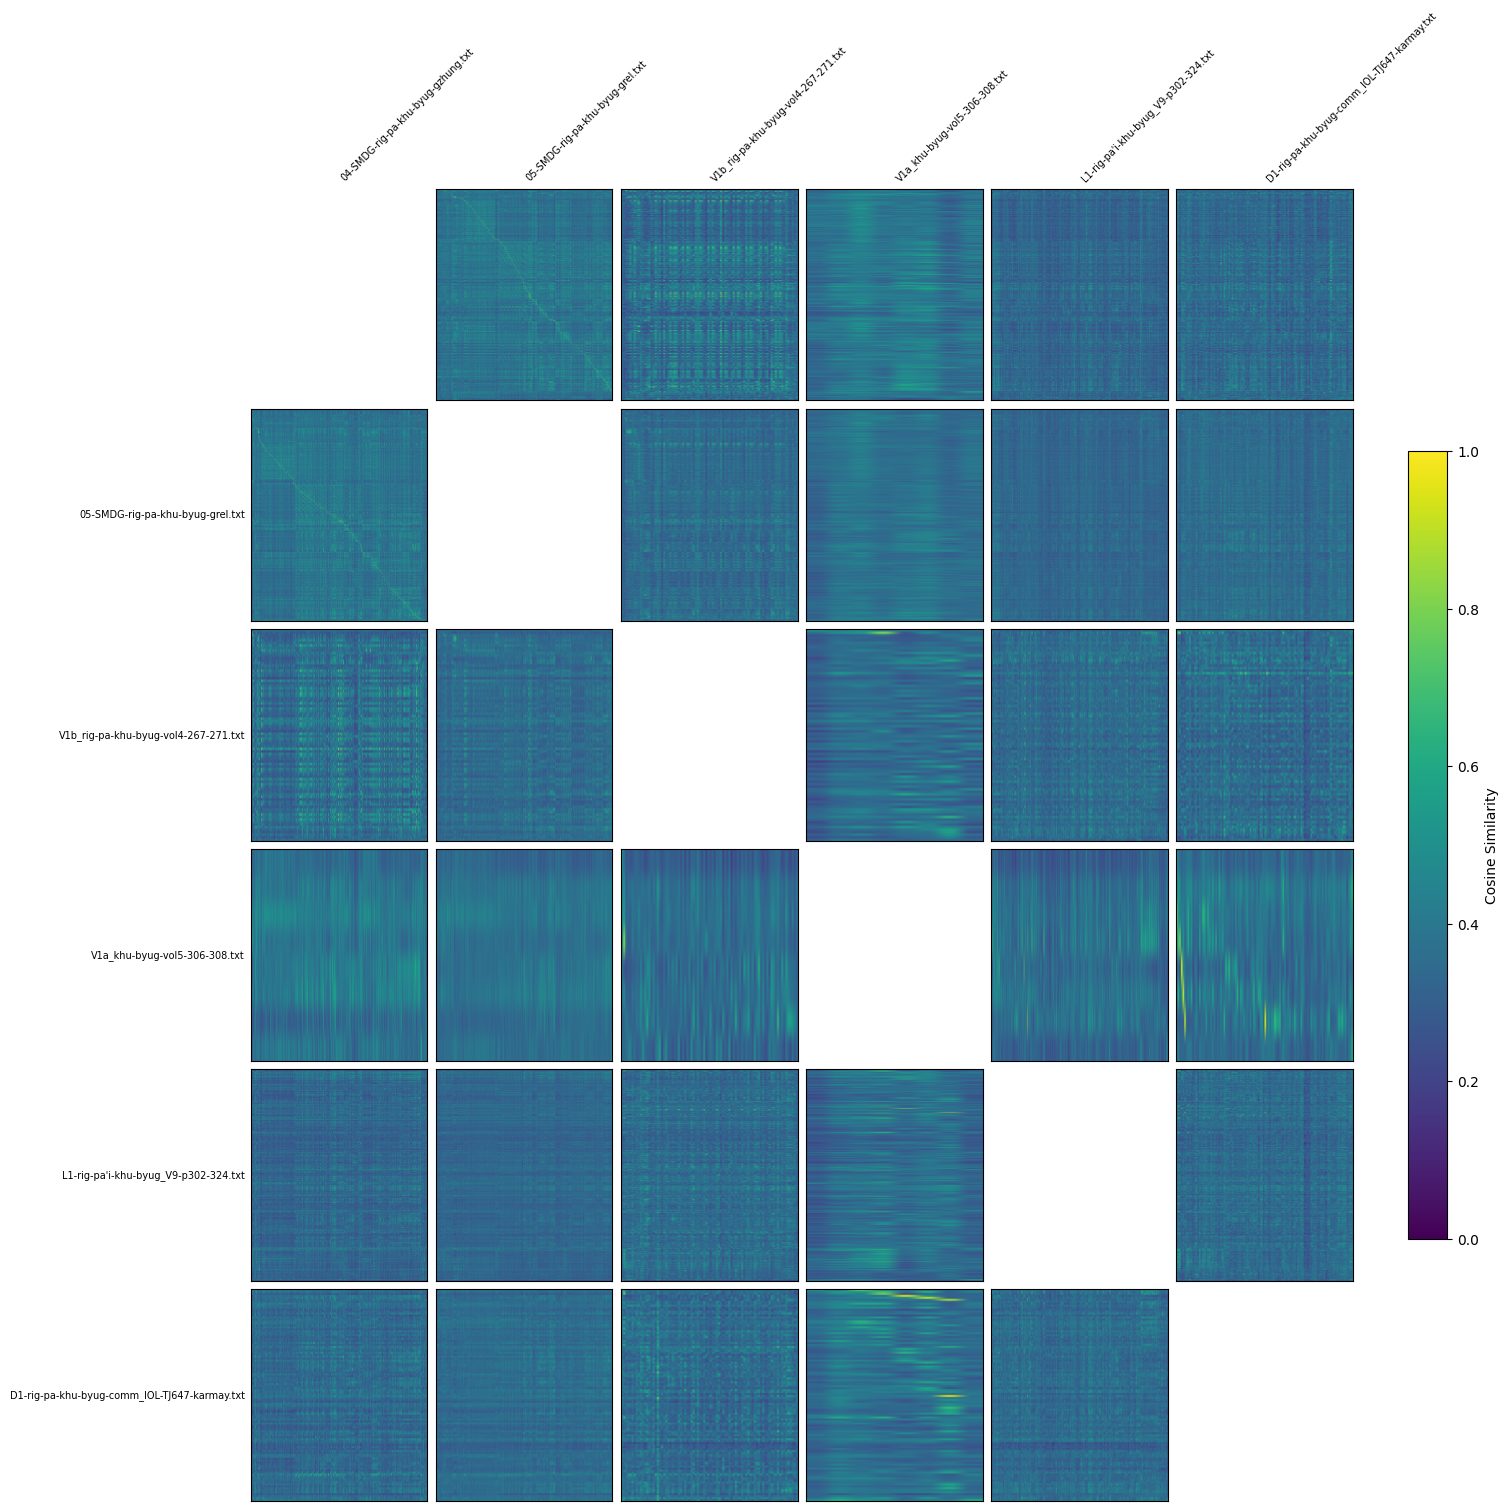

In [19]:
# We plot a matrix with all pairwise heatmaps
# IMPORTANT: Note that the heatmaps are stretched because the dimensionalities vary so greatly
# This does not really make sense...
import matplotlib.pyplot as plt

text_names = [text.name for text in loaded_data]
n = len(text_names)
name_to_idx = {name: i for i, name in enumerate(text_names)}

fig, axes = plt.subplots(n, n, figsize=(2.5*n, 2.5*n), constrained_layout=True)

im = None
for text_a_name, text_b_name, pairwise_result in results:
    i, j = name_to_idx[text_a_name], name_to_idx[text_b_name]
    matrix = pairwise_result.similarity_matrix
    im = axes[i, j].imshow(matrix, cmap="viridis", vmin=0, vmax=1, aspect="auto")
    axes[j, i].imshow(matrix.T, cmap="viridis", vmin=0, vmax=1, aspect="auto")

for i in range(n):
    axes[i, i].axis("off")

for i in range(n):
    for j in range(n):
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])

for j in range(n):
    axes[0, j].set_title(text_names[j], fontsize=7, rotation=45, ha="left")

for i in range(n):
    axes[i, 0].set_ylabel(text_names[i], fontsize=7, rotation=0, ha="right", va="center")

fig.colorbar(im, ax=axes, shrink=0.6, label="Cosine Similarity")
plt.savefig("images/heatmap_plot.png", dpi=300, bbox_inches="tight")
plt.show()

Die Heatmaps sind ziemlicher Sondermüll. Schauen wir uns lieber die konkreten Stats der Embeddings vergleiche an.

Lass uns mal lieber anhand der Top Ähnlichkeiten schauen, wie ähnlich die Texte sind.

In [20]:
help(results[0][2].metrics)

Help on PairwiseMetrics in module tibetan_pipeline.pairwise_run object:

class PairwiseMetrics(builtins.object)
 |  PairwiseMetrics(max_score: 'float', mean_score: 'float', median_score: 'float', p95_score: 'float', mean_above_p95: 'float', mean_best_a_to_b: 'float', mean_best_b_to_a: 'float') -> None
 |  
 |  Aggregate metrics derived from one similarity matrix.
 |  
 |  Methods defined here:
 |  
 |  __eq__(self, other)
 |      Return self==value.
 |  
 |  __init__(self, max_score: 'float', mean_score: 'float', median_score: 'float', p95_score: 'float', mean_above_p95: 'float', mean_best_a_to_b: 'float', mean_best_b_to_a: 'float') -> None
 |      Initialize self.  See help(type(self)) for accurate signature.
 |  
 |  __repr__(self)
 |      Return repr(self).
 |  
 |  ----------------------------------------------------------------------
 |  Data descriptors defined here:
 |  
 |  max_score
 |  
 |  mean_above_p95
 |  
 |  mean_best_a_to_b
 |  
 |  mean_best_b_to_a
 |  
 |  mean_score

In [21]:
import pandas as pd
import numpy as np

text_names = [text.name for text in loaded_data]

df_mean_scores = pd.DataFrame(
    np.nan, index=text_names, columns=text_names
)

# Diagonale über .loc setzen statt np.fill_diagonal
for name in text_names:
    df_mean_scores.loc[name, name] = 1.0

# Werte eintragen (symmetrisch)
for text_a_name, text_b_name, pairwise_result in results:
    score = pairwise_result.metrics.max_score
    df_mean_scores.loc[text_a_name, text_b_name] = score
    df_mean_scores.loc[text_b_name, text_a_name] = score

df_mean_scores

,04-SMDG-rig-pa-khu-byug-gzhung.txt,05-SMDG-rig-pa-khu-byug-grel.txt,V1b_rig-pa-khu-byug-vol4-267-271.txt,V1a_khu-byug-vol5-306-308.txt,L1-rig-pa'i-khu-byug_V9-p302-324.txt,D1-rig-pa-khu-byug-comm_IOL-TJ647-karmay.txt
04-SMDG-rig-pa-khu-byug-gzhung.txt,1.000000,0.954766,0.844302,0.591657,0.736389,0.697430
05-SMDG-rig-pa-khu-byug-grel.txt,0.954766,1.000000,0.829751,0.651235,0.772975,0.740196
V1b_rig-pa-khu-byug-vol4-267-271.txt,0.844302,0.829751,1.000000,0.796348,0.939272,0.746245
V1a_khu-byug-vol5-306-308.txt,0.591657,0.651235,0.796348,1.000000,0.964024,0.926498
L1-rig-pa'i-khu-byug_V9-p302-324.txt,0.736389,0.772975,0.939272,0.964024,1.000000,0.932239
D1-rig-pa-khu-byug-comm_IOL-TJ647-karmay.txt,0.697430,0.740196,0.746245,0.926498,0.932239,1.000000


Am aussagekräftigsten sind hier noch max_score und p95_score.

In [22]:
import pandas as pd
import numpy as np

text_names = [text.name for text in loaded_data]

df_mean_scores = pd.DataFrame(
    np.nan, index=text_names, columns=text_names
)

# Diagonale über .loc setzen statt np.fill_diagonal
for name in text_names:
    df_mean_scores.loc[name, name] = 1.0

# Werte eintragen (symmetrisch)
for text_a_name, text_b_name, pairwise_result in results:
    score = pairwise_result.metrics.p95_score
    df_mean_scores.loc[text_a_name, text_b_name] = score
    df_mean_scores.loc[text_b_name, text_a_name] = score

df_mean_scores

,04-SMDG-rig-pa-khu-byug-gzhung.txt,05-SMDG-rig-pa-khu-byug-grel.txt,V1b_rig-pa-khu-byug-vol4-267-271.txt,V1a_khu-byug-vol5-306-308.txt,L1-rig-pa'i-khu-byug_V9-p302-324.txt,D1-rig-pa-khu-byug-comm_IOL-TJ647-karmay.txt
04-SMDG-rig-pa-khu-byug-gzhung.txt,1.000000,0.523087,0.534731,0.491875,0.445794,0.441714
05-SMDG-rig-pa-khu-byug-grel.txt,0.523087,1.000000,0.490224,0.476734,0.442577,0.448949
V1b_rig-pa-khu-byug-vol4-267-271.txt,0.534731,0.490224,1.000000,0.469129,0.474623,0.471295
V1a_khu-byug-vol5-306-308.txt,0.491875,0.476734,0.469129,1.000000,0.494806,0.541630
L1-rig-pa'i-khu-byug_V9-p302-324.txt,0.445794,0.442577,0.474623,0.494806,1.000000,0.460689
D1-rig-pa-khu-byug-comm_IOL-TJ647-karmay.txt,0.441714,0.448949,0.471295,0.541630,0.460689,1.000000


In [23]:
import pandas as pd
import numpy as np

text_names = [text.name for text in loaded_data]

df_mean_scores = pd.DataFrame(
    np.nan, index=text_names, columns=text_names
)

# Diagonale über .loc setzen statt np.fill_diagonal
for name in text_names:
    df_mean_scores.loc[name, name] = 1.0

# Werte eintragen (symmetrisch)
for text_a_name, text_b_name, pairwise_result in results:
    score = pairwise_result.metrics.mean_above_p95
    df_mean_scores.loc[text_a_name, text_b_name] = score
    df_mean_scores.loc[text_b_name, text_a_name] = score

df_mean_scores

,04-SMDG-rig-pa-khu-byug-gzhung.txt,05-SMDG-rig-pa-khu-byug-grel.txt,V1b_rig-pa-khu-byug-vol4-267-271.txt,V1a_khu-byug-vol5-306-308.txt,L1-rig-pa'i-khu-byug_V9-p302-324.txt,D1-rig-pa-khu-byug-comm_IOL-TJ647-karmay.txt
04-SMDG-rig-pa-khu-byug-gzhung.txt,1.000000,0.578011,0.596099,0.521144,0.490833,0.477037
05-SMDG-rig-pa-khu-byug-grel.txt,0.578011,1.000000,0.547615,0.507948,0.484024,0.482598
V1b_rig-pa-khu-byug-vol4-267-271.txt,0.596099,0.547615,1.000000,0.522896,0.527336,0.516282
V1a_khu-byug-vol5-306-308.txt,0.521144,0.507948,0.522896,1.000000,0.555018,0.624404
L1-rig-pa'i-khu-byug_V9-p302-324.txt,0.490833,0.484024,0.527336,0.555018,1.000000,0.503172
D1-rig-pa-khu-byug-comm_IOL-TJ647-karmay.txt,0.477037,0.482598,0.516282,0.624404,0.503172,1.000000


In [35]:
import pandas as pd
import numpy as np

text_names = [text.name for text in loaded_data]

df_mean_scores = pd.DataFrame(
    np.nan, index=text_names, columns=text_names
)

# Diagonale über .loc setzen statt np.fill_diagonal
for name in text_names:
    df_mean_scores.loc[name, name] = 1.0

# Werte eintragen (symmetrisch)
for text_a_name, text_b_name, pairwise_result in results:
    score = pairwise_result.metrics.mean_best_a_to_b
    df_mean_scores.loc[text_a_name, text_b_name] = score
    df_mean_scores.loc[text_b_name, text_a_name] = score

df_mean_scores

,04-SMDG-rig-pa-khu-byug-gzhung.txt,05-SMDG-rig-pa-khu-byug-grel.txt,V1b_rig-pa-khu-byug-vol4-267-271.txt,V1a_khu-byug-vol5-306-308.txt,L1-rig-pa'i-khu-byug_V9-p302-324.txt,D1-rig-pa-khu-byug-comm_IOL-TJ647-karmay.txt
04-SMDG-rig-pa-khu-byug-gzhung.txt,1.000000,0.780447,0.549909,0.473407,0.570158,0.505645
05-SMDG-rig-pa-khu-byug-grel.txt,0.780447,1.000000,0.522997,0.453180,0.560888,0.503747
V1b_rig-pa-khu-byug-vol4-267-271.txt,0.549909,0.522997,1.000000,0.447756,0.635744,0.535552
V1a_khu-byug-vol5-306-308.txt,0.473407,0.453180,0.447756,1.000000,0.719579,0.749907
L1-rig-pa'i-khu-byug_V9-p302-324.txt,0.570158,0.560888,0.635744,0.719579,1.000000,0.523029
D1-rig-pa-khu-byug-comm_IOL-TJ647-karmay.txt,0.505645,0.503747,0.535552,0.749907,0.523029,1.000000


In [36]:
import pandas as pd
import numpy as np

text_names = [text.name for text in loaded_data]

df_mean_scores = pd.DataFrame(
    np.nan, index=text_names, columns=text_names
)

# Diagonale über .loc setzen statt np.fill_diagonal
for name in text_names:
    df_mean_scores.loc[name, name] = 1.0

# Werte eintragen (symmetrisch)
for text_a_name, text_b_name, pairwise_result in results:
    score = pairwise_result.metrics.mean_best_b_to_a
    df_mean_scores.loc[text_a_name, text_b_name] = score
    df_mean_scores.loc[text_b_name, text_a_name] = score

df_mean_scores

,04-SMDG-rig-pa-khu-byug-gzhung.txt,05-SMDG-rig-pa-khu-byug-grel.txt,V1b_rig-pa-khu-byug-vol4-267-271.txt,V1a_khu-byug-vol5-306-308.txt,L1-rig-pa'i-khu-byug_V9-p302-324.txt,D1-rig-pa-khu-byug-comm_IOL-TJ647-karmay.txt
04-SMDG-rig-pa-khu-byug-gzhung.txt,1.000000,0.637262,0.632496,0.551331,0.517141,0.503461
05-SMDG-rig-pa-khu-byug-grel.txt,0.637262,1.000000,0.667230,0.601748,0.565619,0.567012
V1b_rig-pa-khu-byug-vol4-267-271.txt,0.632496,0.667230,1.000000,0.575758,0.528695,0.539257
V1a_khu-byug-vol5-306-308.txt,0.551331,0.601748,0.575758,1.000000,0.461900,0.502543
L1-rig-pa'i-khu-byug_V9-p302-324.txt,0.517141,0.565619,0.528695,0.461900,1.000000,0.586937
D1-rig-pa-khu-byug-comm_IOL-TJ647-karmay.txt,0.503461,0.567012,0.539257,0.502543,0.586937,1.000000


## Top K Ergebnisse

In [27]:
unravelled = results[0][2].similarity_matrix.astype(np.float32, copy=False).ravel()

In [34]:
unravelled[unravelled > 0.53].shape[0] / unravelled.shape[0]

0.04406386617127481

In [ ]:
# Sanity check
assert pairwise_results.similarity_matrix.shape[0] == len(loaded_data[0].segments.segments)
assert pairwise_results.similarity_matrix.shape[1] == len(loaded_data[1].segments.segments)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def render_cosine_heatmap(
    matrix,
    row_labels=None,
    col_labels=None,
    title="Matrix Heatmap",
    cmap="viridis",
    figsize=None,
    cbar=True,
    savefig=True,
    filename="heatmap.png"
):
    A = np.asarray(matrix)
    assert A.ndim == 2, "matrix muss 2D sein (n x m)."

    n, m = A.shape

    # Bei großen Dimensionen keine Ticklabels anzeigen (lesbarer + schneller)
    show_row = row_labels is not None and n <= 50
    show_col = col_labels is not None and m <= 50

    if figsize is None:
        figsize = (min(12, m/10), min(10, n/10))

    plt.figure(figsize=figsize)
    ax = sns.heatmap(
        A,
        cmap=cmap,
        annot=False,  # keine Werte einblenden
        xticklabels=(col_labels if show_col else False),
        yticklabels=(row_labels if show_row else False),
        square=False,
        cbar=cbar
    )
    ax.set_title(title)
    ax.set_xlabel("Columns (m)")
    ax.set_ylabel("Rows (n)")
    plt.tight_layout()
    if savefig:
        plt.savefig(f"data/{filename}", dpi=300)
    plt.show()

In [ ]:
render_cosine_heatmap(pairwise_results.similarity_matrix, filename="heatmap_8b.png")

In [ ]:
#pairwise_results.matches

In [ ]:
pairwise_results.topk_dataframe().to_csv("data/topk_matches_04-SMDG_05-SMDG_8b.csv")

**This part is from the original notebook**

In [ ]:
text_a = "བོད་ཀྱི་རི་ཁྲོད་ན་རླུང་གི་སྒྲ་དང་ཆུ་ཡི་སྒྲ་གཉིས་མཉམ་དུ་ཐོས་པ་ཡོད། ཉི་མ་ཤར་བའི་དུས་སུ་རི་རྩེ་དང་གངས་རི་དག་ལ་གསལ་པོར་འོད་འཕྲོ་བ་མཐོང་ཐུབ། མི་ཚོས་ས་ཆ་དེར་ཞི་བའི་སེམས་དང་དགའ་བ་ཆེན་པོ་མྱོང་གི་ཡོད། རང་བཞིན་གྱི་མཛེས་སྡུག་དེས་མི་ཚོའི་སེམས་ལ་བདེ་བ་སྐྱེད་པ་ཡིན།"
text_b = "སློབ་གྲྭའི་ནང་དུ་སློབ་མ་ཚོས་ཉིན་རེར་ཤེས་ཡོན་གསར་པ་མང་པོ་སློབ་ཀྱི་ཡོད། དགེ་རྒན་ཚོས་སློབ་མ་རྣམས་ལ་དྲི་བ་འདྲི་བ་དང་གསལ་བཤད་བྱས་ཏེ་རིག་པ་འཕེལ་བར་བྱེད། སློབ་མ་ཚོས་མཉམ་དུ་ལས་ཀ་བྱས་པ་དང་གྲོས་བསྡུར་བྱས་པས་སློབ་སྦྱོང་ལ་དགའ་བ་སྐྱེས། དེ་ལས་སློབ་མ་ཚོའི་མི་ཚེའི་མདུན་ལམ་ཡང་དེ་བས་གསལ་བོ་འགྱོ་བ་ཡིན།"

seg_a = sdk.segment_text(text_a)
seg_b = sdk.segment_text(text_b)

display(seg_a.to_dataframe())
display(seg_b.to_dataframe())


## Check 1: Embedder caching

Expected result:
- `len(sdk._embedders)` stays at `1` after multiple `embed_sentences(...)` calls with the same model-load settings.
- The embedder object id stays the same even if `batch_size` or `embedding_progress` changes.
- The second call may still do inference work, but it should not require a fresh model load.


In [ ]:
t0 = perf_counter()
embedding_view_a = sdk.embed_sentences(seg_a.segments)
t1 = perf_counter()

embedder_ids_after_first = [id(embedder) for embedder in sdk._embedders.values()]
cache_size_after_first = len(sdk._embedders)

t2 = perf_counter()
embedding_view_b = sdk.embed_sentences(
    seg_b.segments,
    batch_size=2,
    embedding_progress="batch",
)
t3 = perf_counter()

embedder_ids_after_second = [id(embedder) for embedder in sdk._embedders.values()]
cache_size_after_second = len(sdk._embedders)

assert cache_size_after_first == 1
assert cache_size_after_second == 1
assert embedder_ids_after_first == embedder_ids_after_second

print({
    "cache_size_after_first": cache_size_after_first,
    "cache_size_after_second": cache_size_after_second,
    "embedder_ids_after_first": embedder_ids_after_first,
    "embedder_ids_after_second": embedder_ids_after_second,
    "first_call_seconds": round(t1 - t0, 3),
    "second_call_seconds": round(t3 - t2, 3),
})

display(embedding_view_a.to_dataframe().head())
display(embedding_view_b.to_dataframe().head())


## Check 2: `pairwise()` should reuse the SDK segmenter

This cell patches `tibetan_pipeline.sdk.resolve_segmenter` to raise if it is called after SDK construction. If the fix worked, `sdk.pairwise(...)` still succeeds because it reuses `sdk._segmenter`.


In [ ]:
with patch("tibetan_pipeline.sdk.resolve_segmenter", side_effect=AssertionError("pairwise() should not construct a new segmenter")):
    pairwise_view = sdk.pairwise(text_a, text_b, top_k=5, batch_size=2)

display(pairwise_view.topk_dataframe())
print({
    "pairwise_segments_a": len(pairwise_view.segments_a),
    "pairwise_segments_b": len(pairwise_view.segments_b),
    "similarity_shape": pairwise_view.similarity_matrix.shape,
    "cached_embedders": len(sdk._embedders),
})


In [ ]:
saraswati_praise_text = """
༄༅། །སྒྲ་དབྱངས་ལྷ་མོ་དབྱངས་ཅན་མ་ལ་བསྟོད་པ།
 
ཨོཾ་བདེ་ལེགས་སུ་གྱུར་ཅིག
 

ཆུ་འཛིན་དཀར་པོའི་གློག་ཕྲེང་དྲ་བ་ཅན། །
མཁའ་ཡི་མཛེས་བྱེད་འདྲ་བའི་ཡིད་འཕྲོག་མ། །
དྲི་ཟའི་ན་ཆུང་དབུས་ན་འཇོ་སྒེག་མཁན། །
རིང་ནས་བརྩེ་བའི་ལྷ་མོ་ད་ཚུར་བྱོན། །
 

པད་མའི་བཞིན་ལ་གཡོ་ལྡན་བུང་བའི་མིག །
མཐོན་མཐིང་རལ་པའི་རྩེ་ན་འོད་དཀར་ཅན། །
རོལ་སྒེག་གར་གྱིས་འགྱིང་བའི་དབྱངས་ཅན་མ། །
ད་དུང་བདག་ལ་ངག་གི་དངོས་གྲུབ་སྩོལ། །
 

རོལ་རྩེད་གར་གྱི་ཉམས་ལྡན་རི་དྭགས་མིག །
མིག་གིས་བལྟ་བས་མི་ངོམ་ཡིད་འཕྲོག་མ། །
མ་ལྟར་བརྩེ་བ་ཁྱེད་ཀྱིས་བདག་གི་ངག །
ངག་དབང་ལྷ་མོ་ཉིད་དང་མཚུངས་པར་མཛོད། །
 

སྟོན་ཟླ་རྒྱས་པའི་དཔལ་ལས་ལྷག་པར་མཛེས། །
ཚངས་དབྱངས་སྙན་པའི་གདངས་ཀྱང་ཟིལ་གྱིས་གནོན། །
ཟབ་ཡངས་རྒྱ་མཚོའི་འཇིང་ལྟར་དཔག་དཀའ་བ། །
དབྱངས་ཅན་ལྷ་མོའི་སྐུ་གསུང་ཐུགས་ལ་འདུད། །
"""

In [ ]:
foundation_of_all_good_qualities_text = """
༄༅། །ཡོན་ཏན་གཞིར་གྱུར་མ་བཞུགས་སོ། །
 

ཡོན་ཏན་ཀུན་གྱི་གཞིར་གྱུར་དྲིན་ཅན་རྗེ། །
ཚུལ་བཞིན་བསྟེན་པ་ལམ་གྱི་རྩ་བ་རུ། །
ལེགས་པར་མཐོང་ནས་འབད་པ་དུ་མ་ཡིས། །
གུས་པ་ཆེན་པོས་བསྟེན་པར་བྱིན་གྱིས་རློབས། །
 

ལན་ཅིག་རྙེད་པའི་དལ་བའི་རྟེན་བཟང་འདི། །
ཤིན་ཏུ་རྙེད་དཀའ་དོན་ཆེ་ཤེས་གྱུར་ནས། །
ཉིན་མཚན་ཀུན་ཏུ་སྙིང་པོ་ལེན་པའི་བློ། །
རྒྱུན་ཆད་མེད་པར་སྐྱེ་བར་བྱིན་གྱིས་རློབས། །
 

ལུས་སྲོག་གཡོ་བ་ཆུ་ཡི་ཆུ་བུར་བཞིན། །
མྱུར་དུ་འཇིག་པའི་འཆི་བ་དྲན་པ་དང༌། །
ཤི་བའི་རྗེས་སུ་ལུས་དང་གྲིབ་མ་བཞིན། །
དཀར་ནག་ལས་འབྲས་ཕྱི་བཞིན་འབྲང་བ་ལ། །
 

ངེས་པ་བརྟན་པོ་རྙེད་ནས་ཉེས་པའི་ཚོགས། །
ཕྲ་ཞིང་ཕྲ་བ་རྣམས་ཀྱང་སྤོང་བ་དང༌། །
དགེ་ཚོགས་མཐའ་དག་སྒྲུབ་པར་བྱེད་པ་ལ། །
རྟག་ཏུ་བག་དང་ལྡན་པར་བྱིན་གྱིས་རློབས། །
 

སྤྱད་པས་མི་ངོམས་སྡུག་བསྔལ་ཀུན་གྱི་སྒོ། །
ཡིད་བརྟན་མི་རུང་སྲིད་པའི་ཕུན་ཚོགས་ཀྱི། །
ཉེས་དམིགས་རིག་ནས་ཐར་བའི་བདེ་བ་ལ། །
དོན་གཉེར་ཆེན་པོ་སྐྱེ་བར་བྱིན་གྱིས་རློབས། །
 

རྣམ་དག་བསམ་པ་དེ་ཡིས་དྲངས་པ་ཡི། །
དྲན་དང་ཤེས་བཞིན་བག་ཡོད་ཆེན་པོ་ཡིས། །
བསྟན་པའི་རྩ་བ་སོ་སོར་ཐར་བ་ལ། །
སྒྲུབ་པ་སྙིང་པོར་བྱེད་པར་བྱིན་གྱིས་རློབས། །
 

རང་ཉིད་སྲིད་མཚོར་ལྷུང་བ་ཇི་བཞིན་དུ། །
མར་གྱུར་འགྲོ་བ་ཀུན་ཀྱང་དེ་འདྲ་བར། །
མཐོང་ནས་འགྲོ་བ་སྒྲོལ་བའི་ཁུར་འཁྱེར་བའི། །
བྱང་ཆུབ་སེམས་མཆོག་འབྱོངས་པར་བྱིན་གྱིས་རློབས། །
 

སེམས་ཙམ་བསྐྱེད་ཀྱང་ཚུལ་ཁྲིམས་རྣམ་གསུམ་ལ། །
གོམས་པ་མེད་ན་བྱང་ཆུབ་མི་འགྲུབ་པར། །
ལེགས་པར་མཐོང་ནས་རྒྱལ་སྲས་སྡོམ་པ་ལ། །
བརྩོན་པ་དྲག་པོས་སློབ་པར་བྱིན་གྱིས་རློབས། །
 

ལོག་པའི་ཡུལ་ལ་གཡེངས་པ་ཞི་བྱེད་ཅིང༌། །
ཡང་དག་དོན་ལ་ཚུལ་བཞིན་དཔྱོད་པ་ཡིས། །
ཞི་གནས་ལྷག་མཐོང་ཟུང་དུ་འབྲེལ་བའི་ལམ། །
མྱུར་དུ་རྒྱུད་ལ་སྐྱེ་བར་བྱིན་གྱིས་རློབས། །
 

ཐུན་མོང་ལམ་སྦྱང་སྣོད་དུ་གྱུར་པ་ན། །
ཐེག་པ་ཀུན་གྱི་མཆོག་གྱུར་རྡོ་རྗེ་ཐེག།
སྐལ་བཟང་སྐྱེ་བོའི་འཇུག་ངོགས་དམ་པ་དེར། །
བདེ་བླག་ཉིད་དུ་འཇུག་པར་བྱིན་གྱིས་རློབས། །
 

དེ་ཚེ་དངོས་གྲུབ་རྣམ་གཉིས་སྒྲུབ་པའི་གཞི། །
རྣམ་དག་དམ་ཚིག་སྡོམ་པར་གསུངས་པ་ལ། །
བཅོས་མ་མིན་པའི་ངེས་པ་རྙེད་གྱུར་ནས། །
སྲོག་དང་བསྡོས་ཏེ་སྲུང་བར་བྱིན་གྱིས་རློབས། །
 

དེ་ནས་རྒྱུད་སྡེ་སྙིང་པོ་རིམ་གཉིས་ཀྱི། །
གནད་རྣམས་ཇི་བཞིན་རྟོགས་ནས་བརྩོན་པ་ཡིས། །
ཐུན་བཞིའི་རྣལ་འབྱོར་སྤྱོད་ལས་མི་གཡེལ་བར། །
དམ་པའི་གསུང་བཞིན་སྒྲུབ་པར་བྱིན་གྱིས་རློབས། །
 

དེ་ལྟར་ལམ་བཟང་སྟོན་པའི་བཤེས་གཉེན་དང༌། །
ཚུལ་བཞིན་སྒྲུབ་པའི་གྲོགས་རྣམས་ཞབས་བརྟན་ཅིང༌། །
ཕྱི་དང་ནང་གི་བར་དུ་གཅོད་པའི་ཚོགས། །
ཉེ་བར་ཞི་བར་བྱིན་གྱིས་བརླབ་ཏུ་གསོལ། །
 

སྐྱེ་བ་ཀུན་ཏུ་ཡང་དག་བླ་མ་དང་། །
འབྲལ་མེད་ཆོས་ཀྱི་དཔལ་ལ་ལོངས་སྤྱོད་ཅིང་། །
ས་དང་ལམ་གྱི་ཡོན་ཏན་རབ་རྫོགས་ནས། །
རྡོ་རྗེ་འཆང་གི་གོ་འཕང་མྱུར་ཐོབ་ཤོག །
 

ཅེས་པ་འདི་ནི་རྗེ་ཙོང་ཁ་པ་བློ་བཟང་གྲགས་པས་མཛད་པའོ། །
"""

In [ ]:
detailed_pairwise_view = sdk.pairwise(saraswati_praise_text, foundation_of_all_good_qualities_text, top_k=10)
detailed_pairwise_view.topk_dataframe()


## Long-text pairwise from precomputed embeddings

Use `pairwise_from_embedding_views(...)` when you already have embeddings in memory. This avoids the expensive re-embedding step inside `pairwise()`.


In [ ]:
import sys
import importlib

modules_to_reload = [
    "tibetan_pipeline.embeddings",
    "tibetan_pipeline.pairwise",
    "tibetan_pipeline.pipeline",
    "tibetan_pipeline.sdk",
    "tibetan_pipeline",
]

for name in modules_to_reload:
    if name in sys.modules:
        importlib.reload(sys.modules[name])

from tibetan_pipeline import TibetanResearchSDK

sdk_reloaded = TibetanResearchSDK(
      engine="botok_ours",
      model_id="buddhist-nlp/gemma-2-mitra-e",
      device="mps",
      batch_size=1,
)

In [ ]:

t2 = perf_counter()
detailed_pairwise_cached_view = sdk_reloaded.pairwise_from_embedding_views(
    embedding_view_a,
    embedding_view_b,
    top_k=10,
)
t3 = perf_counter()

print({
    "saraswati_segments": len(seg_a.segments),
    "foundation_segments": len(seg_b.segments),
    "embedding_seconds": round(t1 - t0, 3),
    "pairwise_from_embeddings_seconds": round(t3 - t2, 3),
    "similarity_shape": detailed_pairwise_cached_view.similarity_matrix.shape,
})

detailed_pairwise_cached_view.topk_dataframe()


## Check 3: Model loading controls are available

This check verifies that the SDK forwards model-loading options into the cached embedder config.

Worth knowing:
- `torch_dtype` controls weight precision at load time.
- `device_map` lets Transformers place model parts automatically or explicitly.
- `load_in_8bit=True` is mainly useful on CUDA setups with bitsandbytes support.


In [ ]:
sdk_controlled = TibetanResearchSDK(
    engine="botok_ours",
    source_format="unicode",
    model_id="buddhist-nlp/gemma-2-mitra-e",
    device="cpu",
    batch_size=1,
    torch_dtype="float32",
)

controlled_embedder = sdk_controlled._get_embedder(
    model_id=sdk_controlled.model_id,
    batch_size=sdk_controlled.batch_size,
    device=sdk_controlled.device,
    embedding_progress=sdk_controlled.embedding_progress,
    torch_dtype=sdk_controlled.torch_dtype,
    device_map=sdk_controlled.device_map,
    load_in_8bit=sdk_controlled.load_in_8bit,
)

pprint({
    "torch_dtype": controlled_embedder.torch_dtype,
    "device_map": controlled_embedder.device_map,
    "load_in_8bit": controlled_embedder.load_in_8bit,
})


## MPS SDK

In [ ]:
mps_sdk = TibetanResearchSDK(
      engine="botok_ours",
      model_id="buddhist-nlp/gemma-2-mitra-e",
      device="mps",
      batch_size=1,
  )

In [ ]:
with patch("tibetan_pipeline.sdk.resolve_segmenter", side_effect=AssertionError("pairwise() should not construct a new segmenter")):
    mps_pairwise_view = mps_sdk.pairwise(text_a, text_b, top_k=5, batch_size=2)

display(mps_pairwise_view.topk_dataframe())
print({
    "pairwise_segments_a": len(mps_pairwise_view.segments_a),
    "pairwise_segments_b": len(mps_pairwise_view.segments_b),
    "similarity_shape": mps_pairwise_view.similarity_matrix.shape,
    "cached_embedders": len(mps_sdk._embedders),
})


## Optional CUDA-oriented configuration example

Do not run this cell on CPU-only setups. It is here as a copy-paste example for a CUDA machine where you want lower VRAM usage.


In [ ]:
# sdk_cuda_8bit = TibetanResearchSDK(
#     engine="botok_ours",
#     source_format="unicode",
#     model_id="buddhist-nlp/gemma-2-mitra-e",
#     device="cuda",
#     batch_size=4,
#     device_map="auto",
#     load_in_8bit=True,
# )
# sdk_cuda_8bit.embed_sentences(seg_a.segments[:2])
